#K-Means Clustering:
## 🧠 Introduction
K-Means clustering is one of the simplest and most widely used unsupervised machine learning algorithms. Unlike supervised learning, where we have labeled data, K-Means works with unlabeled data and tries to discover hidden patterns by grouping similar data points together.

The main idea behind K-Means is to divide the dataset into K distinct clusters, where each cluster represents a group of similar observations. The algorithm does this by identifying a central point for each cluster, known as a centroid, and assigning data points to the nearest centroid.


#Project Structure becomes:



1.   Theory ✅
2.   Math ✅
3.   Data understanding ✅
4.   Data creation ✅
5.   Visualization ✅
6.   K-Means ✅
7.   Centroids ✅
8.   Cluster interpretation ✅ (NEW)
9.   Evaluation (Silhouette Score) ✅ (NEW)







#⚙️ How the K-Means Algorithm Works
The working of K-Means is iterative and follows a simple but powerful process.

Initially, we choose the number of clusters, represented by K. This value is decided based on the problem or using techniques like the Elbow Method.

Once K is chosen, the algorithm randomly initializes K points in the dataset as initial centroids. These centroids act as the starting point for clustering.

Next, the algorithm assigns each data point to the nearest centroid. The “nearest” is determined using a distance metric, most commonly the Euclidean distance. After all points are assigned, clusters are formed.

Once clusters are formed, the algorithm recalculates the centroid of each cluster by taking the mean of all data points in that cluster. This is why it is called K-Means — because it uses the mean to update cluster centers.

This process of assigning points and updating centroids continues repeatedly until the centroids stop changing significantly. At that point, the algorithm is said to have converged, and the final clusters are obtained.



#📐 Mathematical Understanding

The core of K-Means lies in minimizing the distance between data points and their assigned cluster centers.

##1️⃣ Euclidean Distance

To assign a point to a cluster, K-Means calculates the distance between a data point and each centroid. The most commonly used formula is:
d = $\sqrt{(x_1 - c_1)^2 + (x_2 - c_2)^2}$

Here(x_1 ,x_2) are data points
(c_1,c_2) are centroid

The algorithm assigns the point to the centroid with the smallest distance.

##2️⃣ Centroid Calculation

After assigning points, the centroid is updated using the mean of all points in that cluster:
$$
c = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

This means:

Add all points in a cluster
Divide by number of points

👉 This gives the new center of the cluster

##3️⃣ Objective Function (What K-Means Optimizes)

K-Means tries to minimize the Within-Cluster Sum of Squares (WCSS):

This means:$$∑
𝑖
=
1
𝑘
∑
𝑥
∈
𝐶
𝑖
∣
∣
𝑥
−
𝑐
𝑖
∣
∣
2
∑i=1k​∑x∈Ci​​∣∣x−ci​∣∣2 $$

Reduce the distance between points and their centroid
Make clusters as tight as possible



## 📊 Dataset Understanding

Before applying K-Means clustering, it is important to understand the dataset and the problem we are trying to solve.

In this project, we are working with a synthetic dataset that represents driver behavior. Each data point corresponds to an individual driver, and the dataset contains two main features:

- **Distance_Feature**: This represents the average distance traveled by a driver.
- **Speeding_Feature**: This represents the percentage of time a driver exceeds the speed limit.

These two features help us understand how drivers behave in terms of driving patterns.

---

## 🎯 Objective of the Analysis

The goal of this analysis is to identify patterns in driver behavior by grouping similar drivers together using K-Means clustering.

We are trying to answer the following questions:

- Can we group drivers based on their driving habits?
- Are there distinct categories of drivers based on distance and speeding?
- What type of driving behavior does each cluster represent?

---

## 🧠 Expected Insights

By applying K-Means clustering, we expect to identify different types of drivers such as:

- Drivers who travel long distances but maintain safe speeds  
- Drivers who frequently exceed speed limits  
- Drivers with moderate driving behavior  

Each cluster will represent a group of drivers with similar characteristics, and the centroid of each cluster will represent the average behavior of that group.

---

## 📌 Why Clustering is Useful Here

Since we do not have predefined labels (such as "safe" or "risky"), clustering helps us discover hidden patterns in the data.

K-Means will automatically group similar drivers together based on their features, allowing us to better understand driving behavior without prior assumptions.



In [2]:
import numpy as np

## 🧩 Step 1: Data Creation

To simulate real-world driver behavior, we generate synthetic data using a normal distribution.

We create three clusters representing different types of drivers:

- Cluster 1 → Low distance, low speeding  
- Cluster 2 → High distance, high speeding  
- Cluster 3 → Medium distance, high speeding  

This helps us test how K-Means identifies natural groupings in the data.

In [16]:
cluster1=np.random.normal([40,20],[5,5],size=(2000,2))
cluster2=np.random.normal([60,70],[5,5],size=(2000,2))
cluster3=np.random.normal([20,80],[5,5],size=(2000,2))
data=np.vstack([cluster1,cluster2,cluster3])


## 🧩 Step 2: Creating the DataFrame

The generated data is converted into a Pandas DataFrame for easier manipulation and analysis.

Each row represents a driver, and each column represents a feature.

In [24]:
df=pd.DataFrame(data,columns=['Distance_Feature','Speeding_Feature'])


In [17]:
df.shape

(6000, 2)

In [18]:
df.head()

,Distance_Feature,Speeding_Feature
0,43.164093,17.451051
1,34.460374,23.770070
2,40.644861,8.181672
3,44.978122,20.360367
4,43.851870,18.873888


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Distance_Feature  6000 non-null   float64
 1   Speeding_Feature  6000 non-null   float64
dtypes: float64(2)
memory usage: 93.9 KB


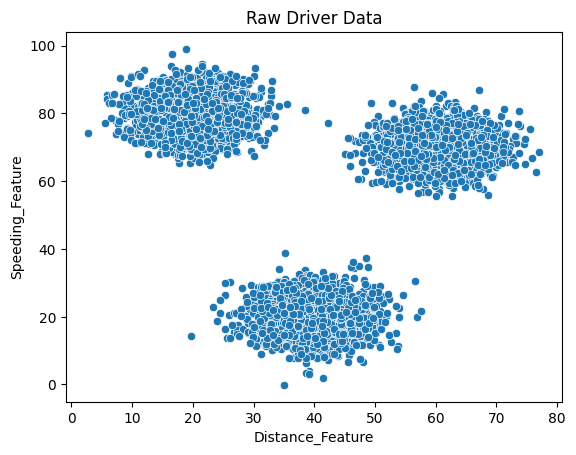

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x='Distance_Feature', y='Speeding_Feature',data=df)
plt.title("Raw Driver Data")
plt.show()

## 🤖 Step 4: Applying K-Means Clustering

We now apply the K-Means algorithm to group the drivers into 3 clusters based on their behavior.

The algorithm assigns each data point to the nearest centroid and updates the centroids iteratively.

In [26]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(df[['Distance_Feature','Speeding_Feature']])

df['Cluster'] = kmeans.labels_

In [28]:
centroids = kmeans.cluster_centers_
centroids

array([[60.29587559, 69.97553362],
       [40.01982968, 20.1744969 ],
       [20.03484106, 79.98397683]])

## 🎨 Step 5: Visualizing Clusters

After applying K-Means, each data point is assigned to a cluster.

We visualize the clusters using different colors to clearly distinguish between groups.

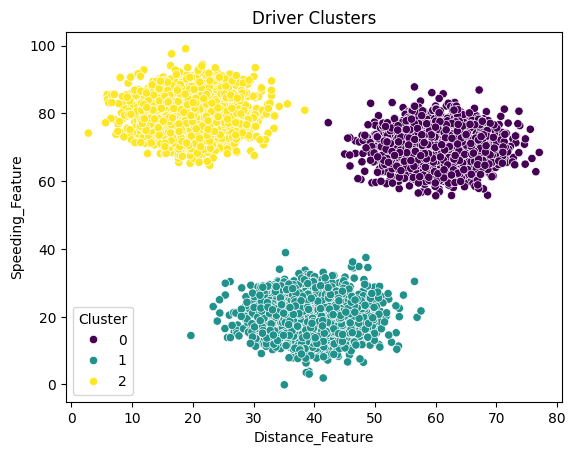

In [31]:
sns.scatterplot(
    x='Distance_Feature',
    y='Speeding_Feature',
    hue='Cluster',
    palette='viridis',
    data=df
)

plt.title("Driver Clusters")
plt.show()

## 📍 Step 6: Plotting Centroids

Centroids represent the center of each cluster.

They help us understand the average behavior of drivers in each group.

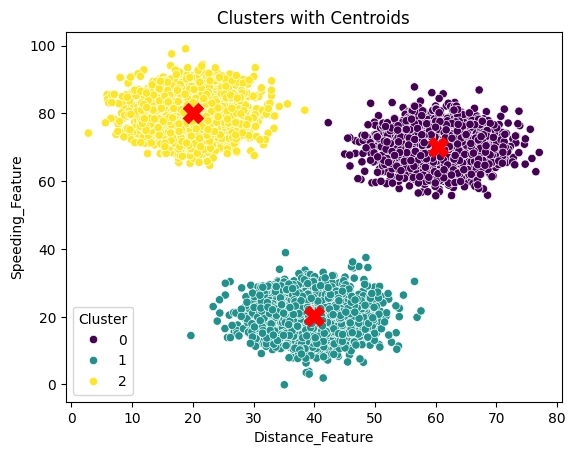

In [32]:
centroids = kmeans.cluster_centers_

sns.scatterplot(
    x='Distance_Feature',
    y='Speeding_Feature',
    hue='Cluster',
    palette='viridis',
    data=df
)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    color='red',
    marker='X',
    s=200
)

plt.title("Clusters with Centroids")
plt.show()

##Do we need “testing” in K-Means?

👉 ❌ No traditional testing like train/test split

Because:

K-Means is unsupervised learning
No labels → nothing to compare with

👉 So instead of testing, we do:
✔️ Evaluation metrics

##Cluster 0 → High speed, moderate distance → Risky drivers
##Cluster 1 → Low speed, moderate distance → Safe drivers
##Cluster 2 → High distance, high speed → Aggressive drivers

In [33]:
centroids_df = pd.DataFrame(centroids, columns=['Distance_Feature','Speeding_Feature'])
centroids_df

,Distance_Feature,Speeding_Feature
0,60.295876,69.975534
1,40.019830,20.174497
2,20.034841,79.983977


#### 📏 Model Evaluation using Silhouette Score

The Silhouette Score measures how well-separated the clusters are.

In [34]:
from sklearn.metrics import silhouette_score

score = silhouette_score(df[['Distance_Feature','Speeding_Feature']], df['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.8018758095979778


#🧠 Interpretation

1.   Close to 1 → good clustering
2.   Close to 0 → overlapping clusters
3.   Negative → wrong clustering





In [35]:
df['Cluster'].value_counts()
df['Driver_Type'] = df['Cluster'].map({
    0: 'Safe Driver',
    1: 'Moderate Driver',
    2: 'Risky Driver'
})

In [36]:
df.head()

,Distance_Feature,Speeding_Feature,Cluster,Driver_Type
0,43.164093,17.451051,1,Moderate Driver
1,34.460374,23.770070,1,Moderate Driver
2,40.644861,8.181672,1,Moderate Driver
3,44.978122,20.360367,1,Moderate Driver
4,43.851870,18.873888,1,Moderate Driver
